In [ ]:
Program on K-Means Algorithm.

In [1]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris

# Load the Iris dataset as an example
iris = load_iris()
X = iris.data

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Initialize KMeans with the desired number of clusters (e.g., 3)
kmeans = KMeans(n_clusters=3, random_state=42)

# Fit the model to the data
kmeans.fit(X_scaled)

# Get cluster assignments for each data point
labels = kmeans.labels_

# Add cluster labels to the original dataset
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_df['cluster'] = labels

# Print the cluster assignments and centroids (optional)
print(iris_df)
print(kmeans.cluster_centers_)



     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                  5.1               3.5                1.4               0.2   
1                  4.9               3.0                1.4               0.2   
2                  4.7               3.2                1.3               0.2   
3                  4.6               3.1                1.5               0.2   
4                  5.0               3.6                1.4               0.2   
..                 ...               ...                ...               ...   
145                6.7               3.0                5.2               2.3   
146                6.3               2.5                5.0               1.9   
147                6.5               3.0                5.2               2.0   
148                6.2               3.4                5.4               2.3   
149                5.9               3.0                5.1               1.8   

     cluster  
0          1

Model Accuracy: 1.00

Classification Report:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        14
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00         8

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



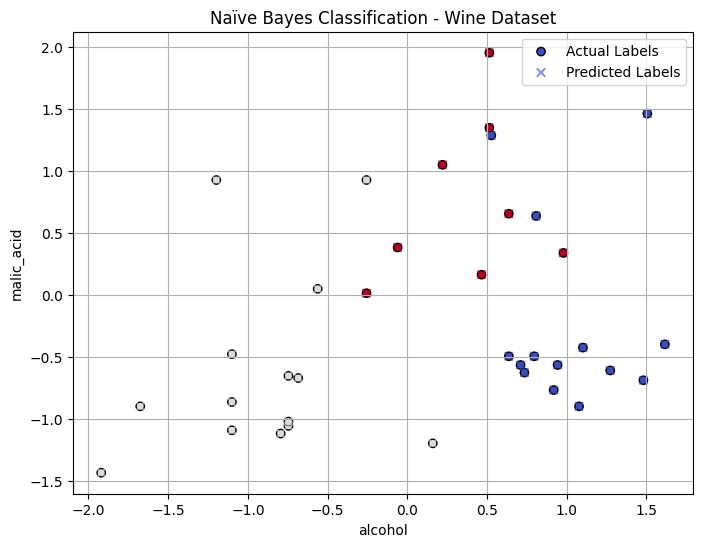

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

# Step 1: Load the Wine Dataset
wine = load_wine()
X, y = wine.data, wine.target # Features and Target labels

# Step 2: Split Data into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Feature Scaling (Recommended for Naïve Bayes)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 4: Train Naïve Bayes Classifier
nb_classifier = GaussianNB()
nb_classifier.fit(X_train_scaled, y_train)

# Step 5: Predict and Evaluate the Model
y_pred = nb_classifier.predict(X_test_scaled)

# Model Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=wine.target_names))

# Step 6: Visualization - Scatter Plot of Two Features
plt.figure(figsize=(8, 6))
plt.scatter(X_test_scaled[:, 0], X_test_scaled[:, 1], c=y_test, cmap='coolwarm', edgecolors='k', label="Actual Labels")
plt.scatter(X_test_scaled[:, 0], X_test_scaled[:, 1], c=y_pred, cmap='coolwarm', marker="x", alpha=0.6, label="Predicted Labels")

plt.xlabel(wine.feature_names[0])
plt.ylabel(wine.feature_names[1])
plt.title("Naïve Bayes Classification - Wine Dataset")
plt.legend(["Actual Labels", "Predicted Labels"])
plt.grid(True)
plt.show()

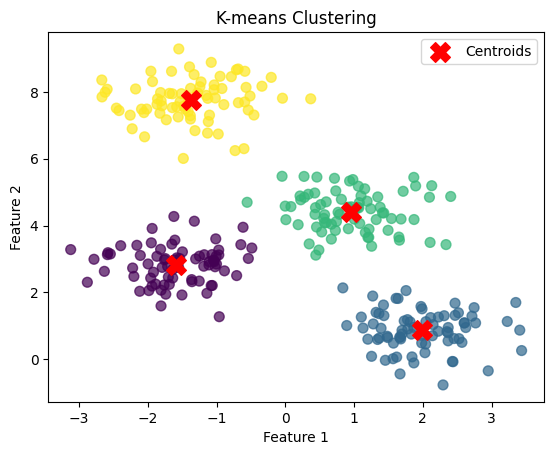

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Step 1: Generate sample data
np.random.seed(42)
X, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)

# Step 2: K-means clustering implementation
def k_means_clustering(X, k, max_iters=100):
    # Randomly initialize centroids
    centroids = X[np.random.choice(X.shape[0], k, replace=False)]

    for _ in range(max_iters):
        # Assign each point to the nearest centroid
        distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
        labels = np.argmin(distances, axis=1)

        # Update centroids
        new_centroids = np.array([X[labels == i].mean(axis=0) for i in range(k)])

        # Check for convergence
        if np.all(centroids == new_centroids):
            break
        centroids = new_centroids

    return labels, centroids

# Step 3: Apply K-means clustering
k = 4
labels, centroids = k_means_clustering(X, k)

# Step 4: Plot the clusters
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=50, alpha=0.7)
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200, label='Centroids')
plt.title('K-means Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()